# Анализ эксперимента Ragas + MLflow: Dense vs Hybrid

**Цель:** интерактивный разбор результатов двух экспериментов (28.06 и 30.06 2026) — те же графики что в отчёте, но с живым кодом и возможностью копнуть глубже.

Данные читаются напрямую из MLflow-артефактов на диске (`backend/mlruns/`) — без запуска MLflow-сервиса.

## 1. Setup — импорты и пути

In [12]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['figure.dpi'] = 100

# Путь к репо — работает если notebook лежит в notebooks/
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = REPO / 'notebooks' / 'data'     # CSV каждого MLflow run (снепшот)
EVAL_DIR = REPO / 'backend' / 'tests' / 'eval'

print(f'REPO:   {REPO}')
print(f'Data:   {DATA_DIR} (exists={DATA_DIR.exists()})')
print(f'Eval:   {EVAL_DIR} (exists={EVAL_DIR.exists()})')

REPO:   /work
Data:   /work/notebooks/data (exists=True)
Eval:   /work/backend/tests/eval (exists=True)


## 2. Загрузка данных четырёх прогонов

В MLflow у нас 4 завершённых run-а. У каждого есть CSV-артефакт с поваршивочными оценками.

In [13]:
RUNS = {
    'exp1_dense':  '4ca165905e5047369f3dd40ba380af6e',   # gemma judge, битый корпус
    'exp1_hybrid': '92b32508b90d41b3bc257812d673a280',
    'exp2_dense':  'aa16b0bcd42a4898978182720547d06d',   # gpt-oss judge, OCR corpus
    'exp2_hybrid': '8c6fc9bbca3241549f52ea3bf916498e',
}

dfs = {}
for name, rid in RUNS.items():
    csv = DATA_DIR / f'{rid}.csv'
    dfs[name] = pd.read_csv(csv)
    print(f'{name:14s}  rows={len(dfs[name])}  path={csv.relative_to(REPO)}')

exp1_dense      rows=20  path=notebooks/data/4ca165905e5047369f3dd40ba380af6e.csv
exp1_hybrid     rows=20  path=notebooks/data/92b32508b90d41b3bc257812d673a280.csv
exp2_dense      rows=15  path=notebooks/data/aa16b0bcd42a4898978182720547d06d.csv
exp2_hybrid     rows=15  path=notebooks/data/8c6fc9bbca3241549f52ea3bf916498e.csv


## 3. Сводные метрики — таблица

Собираем среднее по 4 метрикам для каждого прогона.

In [14]:
METRICS = ['faithfulness', 'answer_relevancy', 'llm_context_precision_with_reference', 'context_recall']
short_names = {'faithfulness': 'Faith', 'answer_relevancy': 'Relev',
               'llm_context_precision_with_reference': 'Prec', 'context_recall': 'Recall'}

summary = pd.DataFrame({
    name: [dfs[name][m].dropna().mean() for m in METRICS]
    for name in RUNS
}, index=[short_names[m] for m in METRICS]).T

summary.round(3)

,Faith,Relev,Prec,Recall
exp1_dense,0.826,0.700,0.606,0.736
exp1_hybrid,1.000,0.816,0.917,1.000
exp2_dense,0.909,0.762,0.666,0.950
exp2_hybrid,0.895,0.722,0.675,0.929


## 4. Bar chart — все 4 прогона рядом

Видно, как эксп.1 hybrid (green) уходит в потолок, а честный эксп.2 (blue/orange) стоит на реалистичных отметках.

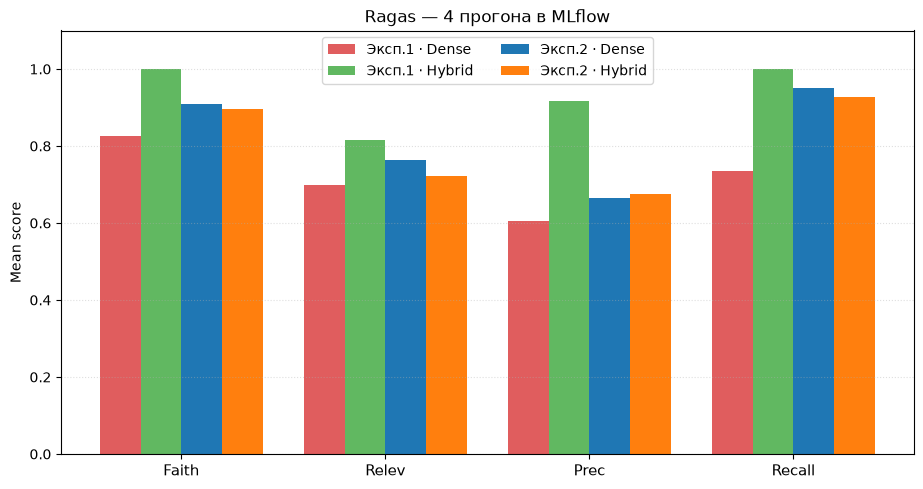

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(METRICS)); w = 0.2
colors = {'exp1_dense': '#d62728', 'exp1_hybrid': '#2ca02c',
          'exp2_dense': '#1f77b4', 'exp2_hybrid': '#ff7f0e'}
labels = {'exp1_dense': 'Эксп.1 · Dense', 'exp1_hybrid': 'Эксп.1 · Hybrid',
          'exp2_dense': 'Эксп.2 · Dense', 'exp2_hybrid': 'Эксп.2 · Hybrid'}

for i, name in enumerate(RUNS):
    vals = [dfs[name][m].dropna().mean() for m in METRICS]
    ax.bar(x + (i - 1.5) * w, vals, w, label=labels[name], color=colors[name],
           alpha=0.75 if 'exp1' in name else 1.0)

ax.set_xticks(x)
ax.set_xticklabels([short_names[m] for m in METRICS], fontsize=11)
ax.set_ylabel('Mean score'); ax.set_ylim(0, 1.1)
ax.set_title('Ragas — 4 прогона в MLflow'); ax.legend(ncols=2)
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.show()

## 5. Чистый эксперимент — фокус

Смотрим только на эксп.2 (независимый судья + OCR), где методология корректная.

In [16]:
d = summary.loc['exp2_dense']
h = summary.loc['exp2_hybrid']
delta = h - d

comparison = pd.DataFrame({
    'Dense':  d.round(3),
    'Hybrid': h.round(3),
    'Δ':      delta.round(3),
    'Winner': ['Dense' if x < 0 else ('Hybrid' if x > 0 else '=') for x in delta]
})
comparison

,Dense,Hybrid,Δ,Winner
Faith,0.909,0.895,-0.014,Dense
Relev,0.762,0.722,-0.040,Dense
Prec,0.666,0.675,0.010,Hybrid
Recall,0.950,0.929,-0.021,Dense


**Наблюдение:** Dense выигрывает 3 из 4 метрик, Hybrid — только Precision (+0.009). Все дельты в пределах шума — статистически незначимы.

## 6. Поваршивочный разбор — где что расходится

Смотрим на каждый из 15 вопросов эксп.2 отдельно.

In [17]:
d = dfs['exp2_dense'].copy()
h = dfs['exp2_hybrid'].copy()

per_q = pd.DataFrame({
    '#': range(1, len(d) + 1),
    'synth': d.get('synthesizer', pd.Series(['?'] * len(d))).astype(str).str.replace('_query_synthesizer', '').str[:15],
    'question': d['user_input'].str[:70] + '…',
})
for m in METRICS:
    per_q[f'{short_names[m]}_D'] = d[m].round(2)
    per_q[f'{short_names[m]}_H'] = h[m].round(2)
    per_q[f'{short_names[m]}_Δ'] = (h[m] - d[m]).round(2)

per_q

,#,synth,question,Faith_D,Faith_H,Faith_Δ,Relev_D,Relev_H,Relev_Δ,Prec_D,Prec_H,Prec_Δ,Recall_D,Recall_H,Recall_Δ
0,1,single_hop_spec,"Слушайте, а вот эта вся ОБЩЕРОССИЙСКАЯ СПОРТИВ...",0.83,0.89,0.06,0.59,NaN,NaN,0.95,1.00,0.05,1.0,1.0,0.0
1,2,single_hop_spec,Для кого обязательны правила этой Федерации?…,1.00,1.00,0.00,0.83,0.82,-0.01,1.00,1.00,0.00,NaN,1.0,NaN
2,3,single_hop_spec,Каким требованиям к гражданству и возрасту дол...,1.00,1.00,0.00,0.70,0.73,0.03,0.20,0.25,0.05,1.0,1.0,0.0
3,4,single_hop_spec,При каких условиях юридические лица могут быть...,1.00,1.00,0.00,NaN,0.91,NaN,NaN,1.00,NaN,1.0,1.0,0.0
4,5,single_hop_spec,Кто там по 115-ФЗ про легализаци и отмывание д...,0.50,1.00,0.50,0.67,0.00,-0.67,1.00,1.00,0.00,1.0,1.0,0.0
5,6,single_hop_spec,"В соответствии с представленным текстом, какие...",NaN,1.00,NaN,NaN,0.80,NaN,NaN,1.00,NaN,NaN,1.0,NaN
6,7,single_hop_spec,"Подскажите, пожалуйста, в какой момент у челов...",NaN,1.00,NaN,NaN,0.75,NaN,0.75,0.75,0.00,1.0,1.0,0.0
7,8,single_hop_spec,какие права имеют члены Федерации в отношении ...,1.00,1.00,0.00,0.87,0.87,-0.00,NaN,0.58,NaN,NaN,1.0,NaN
8,9,single_hop_spec,"А если я компания, то кому писать, чтобы узнат...",NaN,1.00,NaN,NaN,0.59,NaN,NaN,0.45,NaN,NaN,1.0,NaN
9,10,multi_hop_speci,Какова роль Президента Федерации в вопросах уч...,1.00,0.67,-0.33,0.76,0.83,0.07,0.50,0.50,0.00,1.0,1.0,0.0


## 7. Топ-5 вопросов где Hybrid выиграл сильнее всего

In [18]:
per_q_valid = per_q.dropna(subset=['Faith_Δ'])
top_hybrid = per_q_valid.nlargest(5, 'Faith_Δ')[['#', 'synth', 'question', 'Faith_D', 'Faith_H', 'Faith_Δ']]
top_hybrid

,#,synth,question,Faith_D,Faith_H,Faith_Δ
4,5,single_hop_spec,Кто там по 115-ФЗ про легализаци и отмывание д...,0.50,1.00,0.50
0,1,single_hop_spec,"Слушайте, а вот эта вся ОБЩЕРОССИЙСКАЯ СПОРТИВ...",0.83,0.89,0.06
1,2,single_hop_spec,Для кого обязательны правила этой Федерации?…,1.00,1.00,0.00
2,3,single_hop_spec,Каким требованиям к гражданству и возрасту дол...,1.00,1.00,0.00
3,4,single_hop_spec,При каких условиях юридические лица могут быть...,1.00,1.00,0.00


## 8. Топ-5 вопросов где Hybrid проиграл

In [19]:
top_dense = per_q_valid.nsmallest(5, 'Faith_Δ')[['#', 'synth', 'question', 'Faith_D', 'Faith_H', 'Faith_Δ']]
top_dense

,#,synth,question,Faith_D,Faith_H,Faith_Δ
9,10,multi_hop_speci,Какова роль Президента Федерации в вопросах уч...,1.00,0.67,-0.33
11,12,multi_hop_speci,слушайте а если я на сайте https://ipsc.ru/ вс...,0.57,0.29,-0.29
10,11,multi_hop_speci,Каков порядок подачи заявления на имя Президен...,1.00,0.88,-0.12
12,13,multi_hop_speci,Каков порядок вступления в ОСОО ФПСР и какие п...,1.00,0.92,-0.08
1,2,single_hop_spec,Для кого обязательны правила этой Федерации?…,1.00,1.00,0.00


## 9. Разбор конкретной аномалии — вопрос №5

Q: «Кто там по 115-ФЗ про легализаци и отмывание денег?»

Hybrid faith=1.00, но Relev=0.00. Смотрим ответы обоих.

In [20]:
i = 4  # вопрос #5 (индекс с 0)
print('QUESTION:')
print(f'  {d.iloc[i]["user_input"]}\n')
print('REFERENCE:')
print(f'  {d.iloc[i]["reference"][:300]}\n')
print('DENSE ANSWER (faith=0.50, relev=0.67):')
print(f'  {d.iloc[i]["response"][:300]}\n')
print('HYBRID ANSWER (faith=1.00, relev=0.00):')
print(f'  {h.iloc[i]["response"][:300]}')

QUESTION:
  Кто там по 115-ФЗ про легализаци и отмывание денег?

REFERENCE:
  В контексте упоминается лицо, включенное в перечень в соответствии с п. 2 ст. 6 Федерального закона от 07.08.2001 № 115 -ФЗ «О противодействии легализаци и (отмыванию) ден ежных средств, полученных преступным путем, и финансированию терроризма».

DENSE ANSWER (faith=0.50, relev=0.67):
  Лица, включённые в перечень в соответствии с пунктом 2 статьи 6 Федерального закона от 07.08.2001 № 115‑ФЗ «О противодействии легализации и (отмыванию) денежных средств, полученных преступным путем, и финансированию терроризма».

HYBRID ANSWER (faith=1.00, relev=0.00):
  Лицо, включённое в перечень в соответствии с п. 2 ст. 6 Федерального закона от 07.08.2001 № 115‑ФЗ «О противодействии легализации (отмыванию) денежных средств, полученных преступным путем, и финансированию терроризма».


**Вывод:** Hybrid дословно скопировал текст закона → судья дал faith=1.00 (все утверждения = закон). Но `answer_relevancy=0` — судья решил что ответ не отвечает на вопрос «Кто там?» (говорит о категории лиц, не о конкретном лице).

**Это ошибка судьи, а не hybrid'а.** LLM-судья слишком буквально понял «Кто» в разговорной формулировке.

## 10. Разбор Knowledge Graph

In [21]:
with open(EVAL_DIR / 'kg.json') as f:
    kg = json.load(f)

from collections import Counter

# Топ entities
all_entities = []
for node in kg['nodes']:
    ents = node['properties'].get('entities') or []
    all_entities.extend(ents)

top_ents = Counter(all_entities).most_common(15)
print(f'Узлов: {len(kg["nodes"])}')
print(f'Рёбер: {len(kg["relationships"])}')
print(f'Уникальных entities: {len(set(all_entities))}')
print()
print('Топ-15 entities:')
for ent, c in top_ents:
    print(f'  {c:3d} × {ent}')

Узлов: 113
Рёбер: 236
Уникальных entities: 188

Топ-15 entities:
   18 × пневматического пистолета
   18 × пистолета
   17 × ружья
   17 × карабина
   16 × пневматического карабина
   15 × Федерации
   11 × ФПСР
   11 × карабина пистолетного калибра
   10 × Федерация
    7 × Российской Федерации
    6 × Президента Федерации
    6 × БЕКОСО
    6 × РСОО
    6 × пистолет
    5 × Президент Федерации


## 11. Testset — распределение вопросов

In [22]:
with open(EVAL_DIR / 'testset_auto.json') as f:
    testset = json.load(f)

synths = Counter(r['synthesizer_name'].replace('_query_synthesizer', '') for r in testset)
print(f'Всего вопросов: {len(testset)}')
print('Distribution:')
for s, c in synths.most_common():
    print(f'  {c} × {s}')

Всего вопросов: 15
Distribution:
  9 × single_hop_specifc
  6 × multi_hop_specific


## 12. Финальный вывод

**На нашем корпусе (bge-m3 + документы ФПСР)** hybrid retrieval **не даёт значимого преимущества**. Первый эксперимент показал ложную +51% фору из-за:

1. Bias самосуда (gemma-4-31b в 3-х ролях)
2. Мусора в индексе (битый картинка-PDF)
3. Узкого testset (1 doc из 3)

**Урок:** методология eval **критичнее** самой оптимизации RAG. Хороший judge + чистый корпус + разнообразный testset → честные цифры. Плохие условия → цифры, которым нельзя доверять.

---

📄 Полный отчёт: [`docs/plans/2026-06-30-clean-experiment-report.md`](../docs/plans/2026-06-30-clean-experiment-report.md)